# Customer Feedback Text Analysis

This notebook analyzes open-text customer feedback from the experiment.

Goals:
- understand customer sentiment
- identify recurring themes
- detect differences between control and treatment groups

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/experiment_data_cleaned.csv")

df.shape

(647, 15)

## Inspect Customer Comments

The dataset contains open-text feedback from post-call surveys in the `LTR_COMMENT` column.

We first inspect a few comments to understand the type of feedback customers provide.

In [2]:
df["LTR_COMMENT"].dropna().sample(10)

637                                   Very helpful staff
383    Lee who came to install my port for the hun wa...
231    The CS agent and engineer were superb. Install...
91     Easy to join company. With the most friendly a...
69          Extremely helpful engineer on visit Jo 32725
281                Very friendly staff and accommodating
399                              Great customer service.
33     Up and running less than 24h. Fun friendly per...
228    Lady was so nice on the phone as I don¬"t know...
542    After placing an order online with free instal...
Name: LTR_COMMENT, dtype: str

## Comment Availability

We check how many survey responses contain usable open-text feedback.

In [3]:
df["LTR_COMMENT"].notna().sum()

np.int64(482)

## Comment Length Analysis

We calculate the length of customer comments to understand how detailed the feedback is.

In [4]:
df["comment_length"] = df["LTR_COMMENT"].fillna("").str.len()

df["comment_length"].describe()

count     647.000000
mean       89.621329
std       144.310200
min         0.000000
25%         0.000000
50%        37.000000
75%       115.500000
max      1359.000000
Name: comment_length, dtype: float64

## Comment Length Distribution

We visualize the distribution of comment lengths to understand
how detailed customer feedback tends to be.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

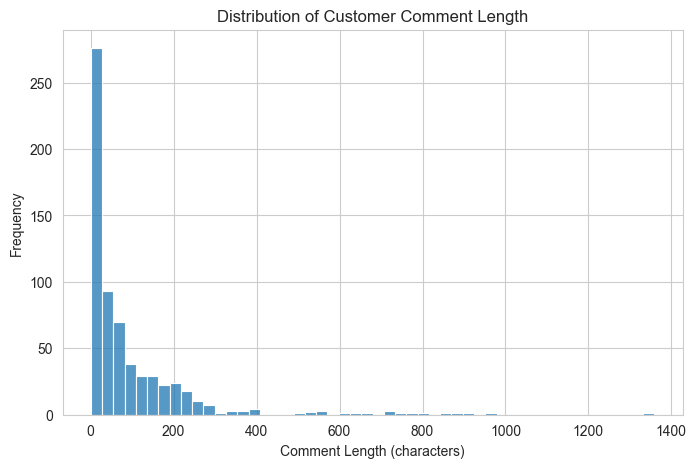

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["comment_length"],
    bins=50
)

plt.title("Distribution of Customer Comment Length")
plt.xlabel("Comment Length (characters)")
plt.ylabel("Frequency")

plt.savefig("../outputs/figures/comment_length_distribution.png", dpi=300)

plt.show()

## Create Clean Comment Dataset

We remove rows with empty comments to create a dataset suitable
for text analysis.

In [8]:
comments_df = df[df["LTR_COMMENT"].notna()].copy()

comments_df.shape

(482, 16)

## Basic Text Cleaning

Before applying NLP methods, we normalize the text by:

- converting to lowercase
- removing punctuation
- removing extra whitespace

In [9]:
import re

def clean_text(text):
    
    text = text.lower()                     # lowercase
    text = re.sub(r"[^\w\s]", "", text)     # remove punctuation
    text = re.sub(r"\s+", " ", text).strip() # remove extra spaces
    
    return text

comments_df["clean_comment"] = comments_df["LTR_COMMENT"].apply(clean_text)

comments_df[["LTR_COMMENT", "clean_comment"]].sample(10)

,LTR_COMMENT,clean_comment
613,We have no experience yet. Installation on Jun...,we have no experience yet installation on june...
158,Charlotta was very helpful,charlotta was very helpful
257,I've been happy with the service from employee...,ive been happy with the service from employees...
352,The experience is really good. The price can b...,the experience is really good the price can be...
322,I have had to call company everyday. 15/05/23 ...,i have had to call company everyday 150523 spo...
182,The process was pretty easy,the process was pretty easy
231,The CS agent and engineer were superb. Install...,the cs agent and engineer were superb installa...
265,"Excellent service from the get go, the gent I ...",excellent service from the get go the gent i s...
236,Very polite and friendly,very polite and friendly
521,Communications terrible,communications terrible


## Filter Very Short Comments

Very short comments may not contain meaningful feedback.
We remove comments shorter than 5 characters.

In [10]:
comments_df = comments_df[comments_df["clean_comment"].str.len() > 5]

comments_df.shape

(478, 17)